<a href="https://colab.research.google.com/github/twyeh/university-physics/blob/%E5%8A%9B%E5%AD%B8/%E8%87%AA%E7%94%B1%E8%90%BD%E9%AB%94%E7%9A%84RNN%E6%A8%A1%E5%9E%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generated free-fall data samples:


,time,height
0,0.000000,99.497337
1,0.004505,100.198443
2,0.009009,101.163120
3,0.013514,100.195286
4,0.018018,99.754137


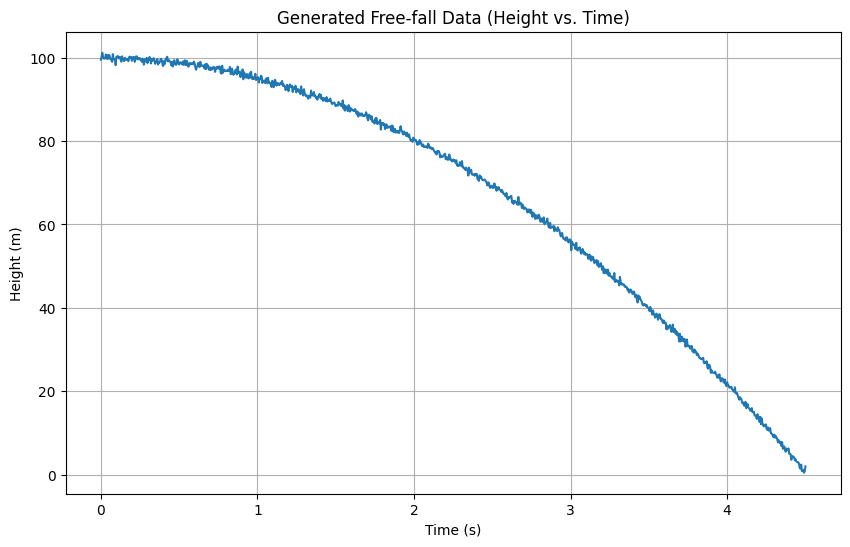

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 1. Generate Free-fall Data
def generate_free_fall_data(initial_height=100, gravity=9.81, max_time=4.5, num_samples=1000, noise_std=0.5):
    time = np.linspace(0, max_time, num_samples)
    height = initial_height - 0.5 * gravity * time**2
    # Ensure height doesn't go below zero
    height[height < 0] = 0

    # Add some noise to simulate real-world measurements
    height += np.random.normal(0, noise_std, num_samples)
    height[height < 0] = 0 # Ensure height remains non-negative after adding noise

    df = pd.DataFrame({'time': time, 'height': height})
    return df

# Generate data
free_fall_df = generate_free_fall_data()

print("Generated free-fall data samples:")
display(free_fall_df.head())

# Visualize the generated data
plt.figure(figsize=(10, 6))
plt.plot(free_fall_df['time'], free_fall_df['height'])
plt.title('Generated Free-fall Data (Height vs. Time)')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.grid(True)
plt.show()


現在我們已經生成了自由落體數據並進行了可視化。接下來，我們需要對數據進行預處理，使其適合RNN模型訓練。這包括數據縮放和將數據轉換為序列格式。

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 6. Function for Iterative Future Prediction
def iterative_predict_future_height(model, scaler, initial_scaled_data, look_back, num_future_steps, time_step_duration):
    """
    Iteratively predicts future free-fall heights beyond the observed data range.

    Args:
        model (keras.Model): The trained RNN model.
        scaler (MinMaxScaler): The fitted scaler used for the height data.
        initial_scaled_data (np.ndarray): The scaled height data, typically the entire dataset.
        look_back (int): The number of previous time steps used for prediction.
        num_future_steps (int): The number of future time steps to predict.
        time_step_duration (float): The duration of each time step in seconds (e.g., df['time'].iloc[1] - df['time'].iloc[0]).

    Returns:
        tuple: A tuple containing:
            - predicted_future_heights (list): List of inverse-transformed predicted heights.
            - future_times (list): List of corresponding future time points.
    """
    # Start with the last 'look_back' known scaled data points
    current_sequence = list(initial_scaled_data[-look_back:].reshape(-1))
    predicted_future_heights = []
    future_times = []

    last_known_time = free_fall_df['time'].iloc[-1]

    for i in range(num_future_steps):
        # Reshape the current sequence for model input: (1, look_back, 1)
        input_sequence = np.array(current_sequence[-look_back:]).reshape(1, look_back, 1)

        # Predict the next step
        predicted_scaled_next_height = model.predict(input_sequence, verbose=0)[0][0]

        # Append the prediction to the list
        predicted_future_heights.append(predicted_scaled_next_height)

        # Add the prediction to the current sequence for the next iteration
        current_sequence.append(predicted_scaled_next_height)

        # Update future time
        future_times.append(last_known_time + (i + 1) * time_step_duration)

    # Inverse transform the predicted scaled heights
    predicted_future_heights_original_scale = scaler.inverse_transform(np.array(predicted_future_heights).reshape(-1, 1))

    return predicted_future_heights_original_scale.flatten(), future_times


Predicted 100 future heights starting from 4.50s:
  Time: 4.50s, Predicted Height: 1.35 m
  Time: 4.51s, Predicted Height: 1.60 m
  Time: 4.51s, Predicted Height: 1.85 m
  Time: 4.52s, Predicted Height: 1.96 m
  Time: 4.52s, Predicted Height: 2.15 m


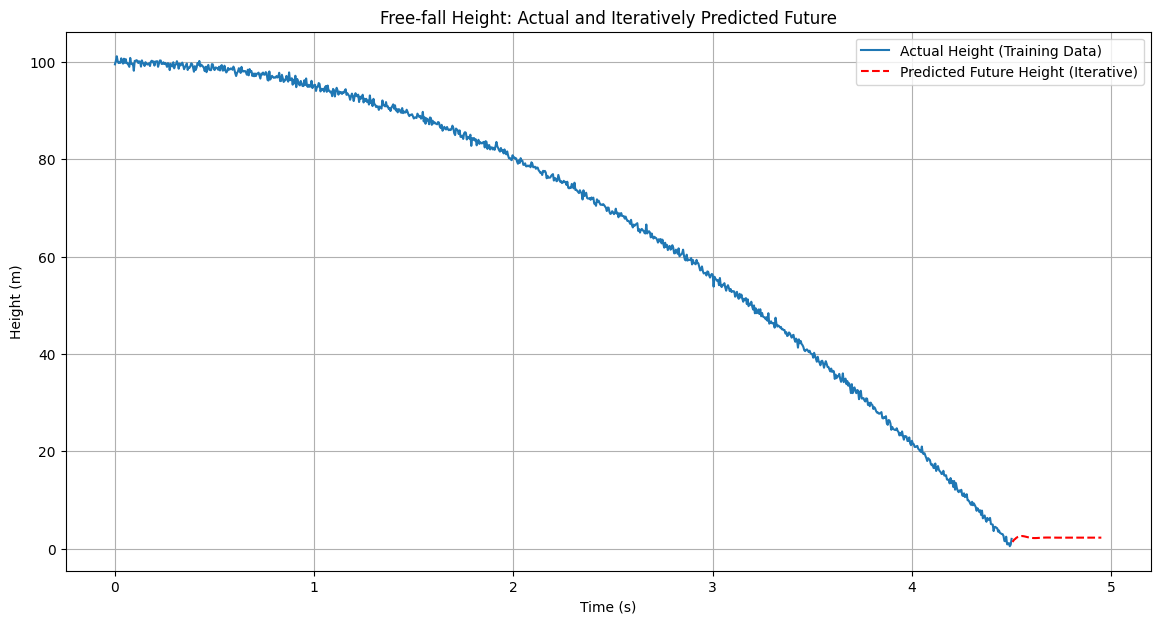

In [8]:
# --- Test the iterative future prediction function ---

# Calculate the time step duration from the original DataFrame
time_step_duration = free_fall_df['time'].iloc[1] - free_fall_df['time'].iloc[0]

num_future_steps = 100 # Predict 100 steps into the future

predicted_heights_future, future_times = iterative_predict_future_height(
    model, scaler, scaled_height, look_back, num_future_steps, time_step_duration
)

print(f"Predicted {num_future_steps} future heights starting from {future_times[0]:.2f}s:")
for i in range(min(5, num_future_steps)): # Print first 5 predictions
    print(f"  Time: {future_times[i]:.2f}s, Predicted Height: {predicted_heights_future[i]:.2f} m")

# Visualize the entire trajectory (actual + predicted future)
plt.figure(figsize=(14, 7))
plt.plot(free_fall_df['time'], free_fall_df['height'], label='Actual Height (Training Data)')
plt.plot(future_times, predicted_heights_future, 'r--', label='Predicted Future Height (Iterative)')
plt.title('Free-fall Height: Actual and Iteratively Predicted Future')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
# 5. Function to predict height at an arbitrary time point

def predict_height_at_time(target_time, df, scaler, model, look_back, scaled_height_data):
    """
    Predicts the free-fall height at a given time point.

    Args:
        target_time (float): The time (in seconds) at which to predict the height.
        df (pd.DataFrame): The original DataFrame with 'time' and 'height'.
        scaler (MinMaxScaler): The fitted scaler used for the height data.
        model (keras.Model): The trained RNN model.
        look_back (int): The number of previous time steps used for prediction.
        scaled_height_data (np.ndarray): The entire scaled height data array.

    Returns:
        float: The predicted height (in meters) at the given time, or None if prediction is not possible.
    """
    # Determine the valid range of time indices for prediction based on look_back
    # The first 'look_back' points don't have enough preceding data for a sequence
    # The last point in `y` corresponds to `scaled_height_data[-1]`.
    # The last `X` sequence corresponds to `scaled_height_data[len(scaled_height_data) - look_back - 1 : len(scaled_height_data) - 1]`
    # and predicts `scaled_height_data[len(scaled_height_data) - 1]`.

    min_predictable_idx = look_back
    max_predictable_idx = len(scaled_height_data) - 1

    min_predictable_time = df['time'].iloc[min_predictable_idx]
    max_predictable_time = df['time'].iloc[max_predictable_idx]

    if not (min_predictable_time <= target_time <= max_predictable_time):
        print(f"Warning: Target time {target_time:.2f}s is outside the model's direct prediction range (from {min_predictable_time:.2f}s to {max_predictable_time:.2f}s).")
        print("This function provides direct prediction for times within the observed data's context.")
        print("For future forecasting beyond the observed range, iterative prediction would be required.")
        return None

    # Find the index in the original scaled_height_data that corresponds to the target_time.
    # We want to predict the height *at* `target_time`. This `target_time` corresponds to an index `target_data_index` in `df`.
    # The model predicts `data[target_data_index]` using `data[target_data_index - look_back : target_data_index]` as input.

    # Find the index where `target_time` would be inserted to maintain sorted order, then step back one.
    target_data_index = df['time'].searchsorted(target_time, side='right') - 1

    # Ensure we have enough preceding data points to form the input sequence
    if target_data_index < look_back:
        print(f"Error: Cannot form a complete input sequence of length {look_back} for target time {target_time:.2f}s.")
        print(f"Requires data from at least {df['time'].iloc[0]:.2f}s to {df['time'].iloc[target_data_index-1]:.2f}s.")
        return None

    # Extract the input sequence from the scaled_height_data
    input_sequence = scaled_height_data[target_data_index - look_back : target_data_index]

    # Reshape the sequence for the model: (1, look_back, 1)
    input_sequence = input_sequence.reshape(1, look_back, 1)

    # Make the prediction
    predicted_scaled_height = model.predict(input_sequence, verbose=0)

    # Inverse transform the prediction to the original scale
    predicted_original_height = scaler.inverse_transform(predicted_scaled_height)

    return predicted_original_height[0][0]

# --- Test the prediction function ---

# Example 1: Predict height at an arbitrary time point within the observed range
test_time_1 = 2.5 # seconds
predicted_height_1 = predict_height_at_time(test_time_1, free_fall_df, scaler, model, look_back, scaled_height)

if predicted_height_1 is not None:
    # Get the actual height for comparison (closest point in original data)
    closest_idx_1 = free_fall_df['time'].searchsorted(test_time_1, side='right') - 1
    actual_height_1 = free_fall_df.loc[closest_idx_1, 'height']
    print(f"\nPrediction for time {test_time_1:.2f}s:")
    print(f"  Predicted Height: {predicted_height_1:.2f} m")
    print(f"  Actual Height (closest): {actual_height_1:.2f} m")

# Example 2: Predict height at a different time point
test_time_2 = 3.8 # seconds
predicted_height_2 = predict_height_at_time(test_time_2, free_fall_df, scaler, model, look_back, scaled_height)

if predicted_height_2 is not None:
    closest_idx_2 = free_fall_df['time'].searchsorted(test_time_2, side='right') - 1
    actual_height_2 = free_fall_df.loc[closest_idx_2, 'height']
    print(f"\nPrediction for time {test_time_2:.2f}s:")
    print(f"  Predicted Height: {predicted_height_2:.2f} m")
    print(f"  Actual Height (closest): {actual_height_2:.2f} m")

# Example 3: Test a time point too early (not enough history)
test_time_early = 0.05 # seconds
predicted_height_early = predict_height_at_time(test_time_early, free_fall_df, scaler, model, look_back, scaled_height)

# Example 4: Test a time point beyond the observed range
test_time_future = 5.0 # seconds (max_time was 4.5)
predicted_height_future = predict_height_at_time(test_time_future, free_fall_df, scaler, model, look_back, scaled_height)



Prediction for time 2.50s:
  Predicted Height: 68.49 m
  Actual Height (closest): 69.08 m

Prediction for time 3.80s:
  Predicted Height: 29.19 m
  Actual Height (closest): 29.63 m
This function provides direct prediction for times within the observed data's context.
For future forecasting beyond the observed range, iterative prediction would be required.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Mean Squared Error (MSE) on test set: 0.4985
Root Mean Squared Error (RMSE) on test set: 0.7060


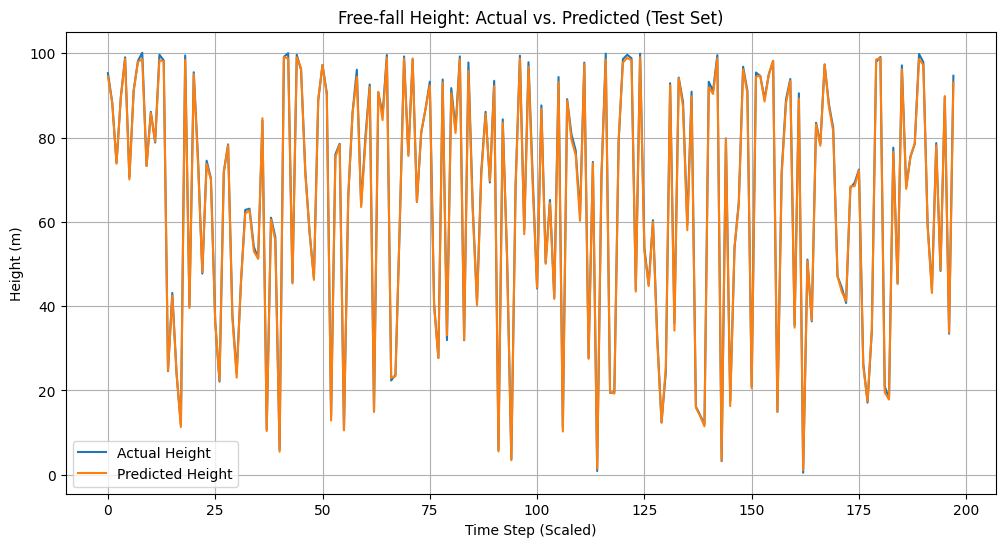

In [5]:
from sklearn.metrics import mean_squared_error

# 4. Make Predictions and Evaluate the Model

# Make predictions on the test set
y_pred_scaled = model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_original = scaler.inverse_transform(y_pred_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE) on test set: {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) on test set: {rmse:.4f}")

# Visualize actual vs. predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label='Actual Height')
plt.plot(y_pred_original, label='Predicted Height')
plt.title('Free-fall Height: Actual vs. Predicted (Test Set)')
plt.xlabel('Time Step (Scaled)')
plt.ylabel('Height (m)')
plt.legend()
plt.grid(True)
plt.show()

現在模型已經評估完畢，我們可以進一步使用它來預測任意時間點的自由落體高度。為了實現這個目標，我們需要一個函數，該函數能夠接收一個時間作為輸入，並返回預測的高度。

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.2687 - val_loss: 0.0075
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0042 - val_loss: 0.0015
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.6419e-04 - val_loss: 7.9701e-05
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.6236e-05 - val_loss: 4.5328e-05
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.3241e-05 - val_loss: 4.5563e-05
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.6582e-05 - val_loss: 3.9292e-05
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.3735e-05 - val_loss: 4.8569e-05
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.6774e-05 - val_loss: 3.7014e-05
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.4944e-05 - val_loss: 3.8567e-05
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.3484e-05 - val_loss: 3.7120e-05
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.1902e-05 - val_loss: 3.6302e-

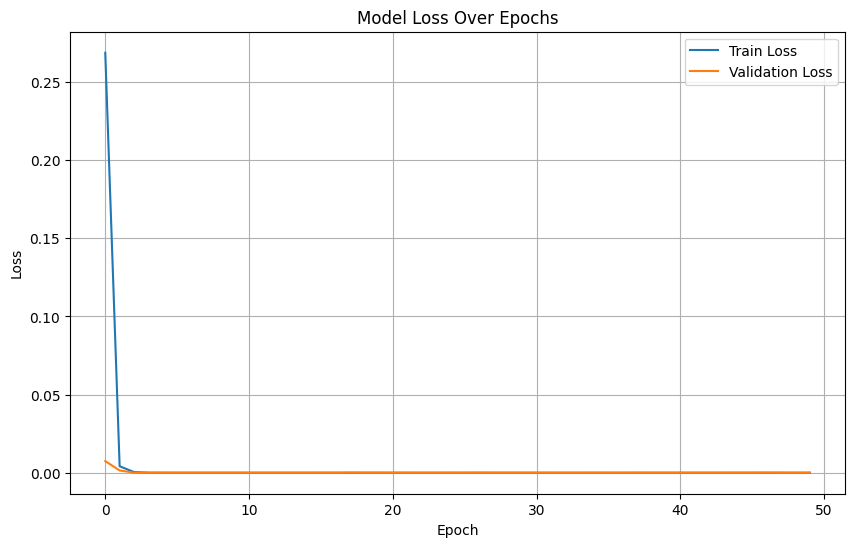

In [4]:
from tensorflow.keras.layers import SimpleRNN, Dense, Input

# 3. Build and Train the SimpleRNN Model

# Define the SimpleRNN model
model = Sequential()
model.add(Input(shape=(look_back, 1))) # Use Input layer explicitly to avoid UserWarning
model.add(SimpleRNN(units=50, activation='relu'))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("Model training complete.")

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

模型訓練完成後，我們現在將評估模型的性能，並使用它來預測自由落體的高度。

In [2]:
# 2. Data Preprocessing for RNN

# Scale the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_height = scaler.fit_transform(free_fall_df['height'].values.reshape(-1, 1))

# Function to create sequences for RNN
def create_sequences(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

# Define look_back window
look_back = 10 # Using 10 previous time steps to predict the next

# Create sequences
X, y = create_sequences(scaled_height, look_back)

# Reshape X to be [samples, time_steps, features] for RNN
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (792, 10, 1)
Shape of y_train: (792,)
Shape of X_test: (198, 10, 1)
Shape of y_test: (198,)


數據預處理完成後，我們現在可以定義、編譯和訓練我們的SimpleRNN模型了。